
SENTINEL 11.0 — COMPARATIVO PRINCIPAL
      Model     FinalEq   Total%  CAGR%  Vol%  Sharpe  Sortino  MaxDD%  Calmar  AvgExp%  TimeInMkt%  TurnoverAnn  CVaR5%
SENTINEL_11  2308424.14  2208.42  16.25 15.03   1.077    1.751  -19.87   0.818     51.5        99.8        10.75  -2.270
   B&H_TECH 12996055.33 12896.06  26.29 25.48   1.044    1.693  -52.76   0.498    100.0       100.0         0.00  -3.782
        QQQ  1706787.78  1606.79  14.58 21.54   0.740    1.176  -53.40   0.273    100.0       100.0         0.00  -3.253
        SPY   782591.53   682.59  10.37 18.99   0.615    0.954  -55.19   0.188    100.0       100.0         0.00  -2.933
       ^NDX  1476093.59  1376.09  13.78 21.97   0.698    1.107  -53.71   0.257    100.0       100.0         0.00  -3.320

STRESS EPISODES
   Episode  CAGR%  Sharpe  MaxDD%  Calmar  AvgExposure%  TimeInMkt%
  GFC_2008  -7.49  -1.200  -11.91  -0.629          12.6        99.2
 EURO_2011  -6.94  -0.713   -8.81  -0.788          30.6       100.0
   Q4_2018 -36

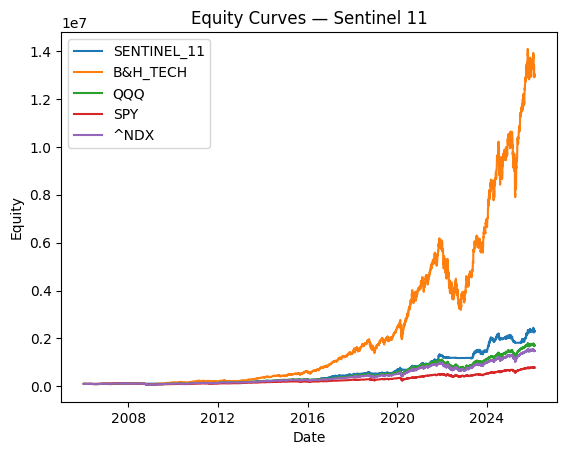

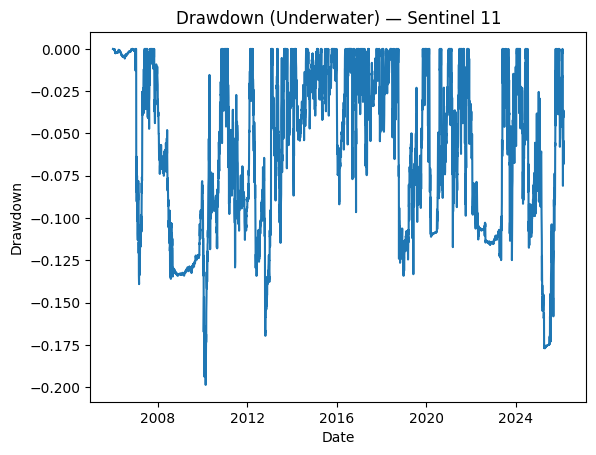

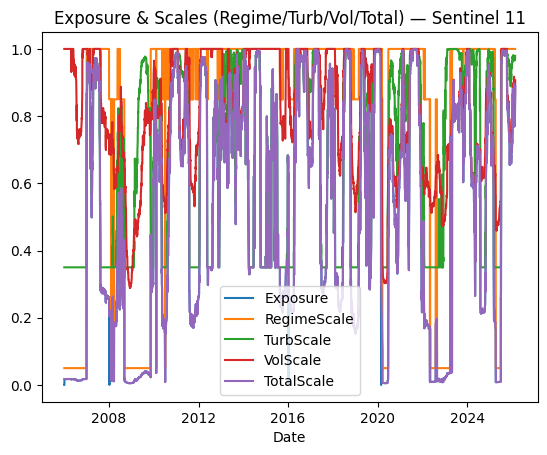

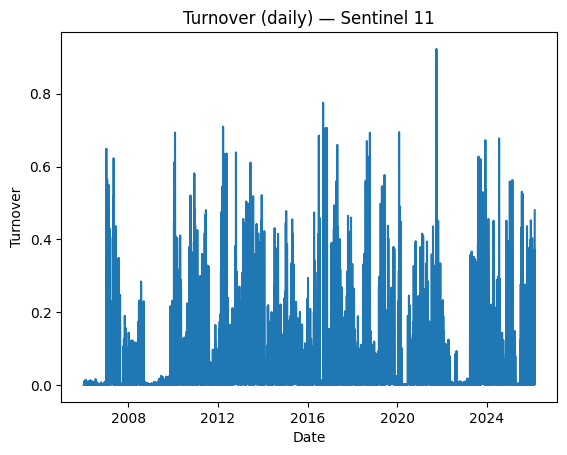

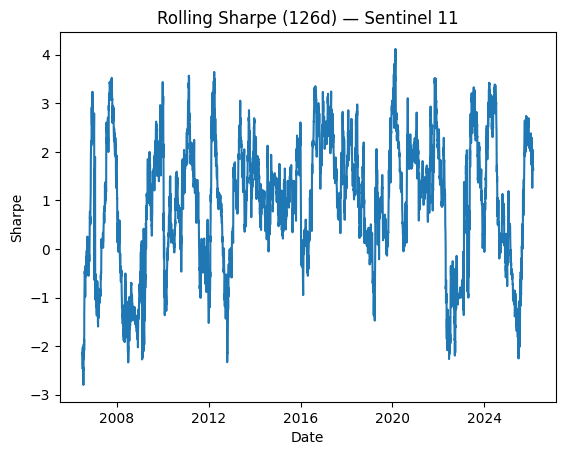

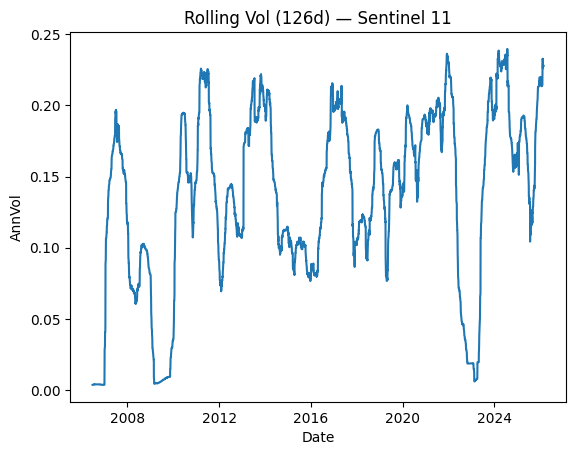

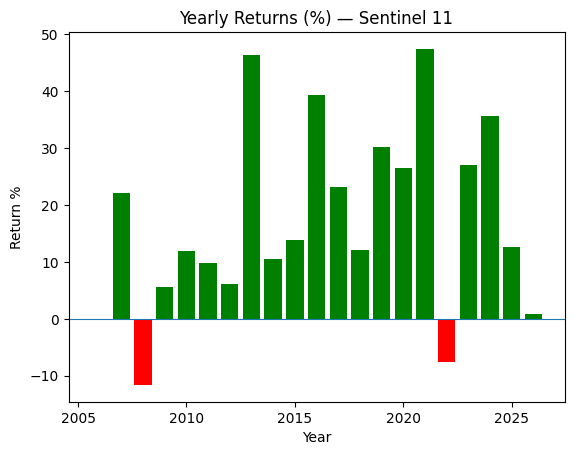

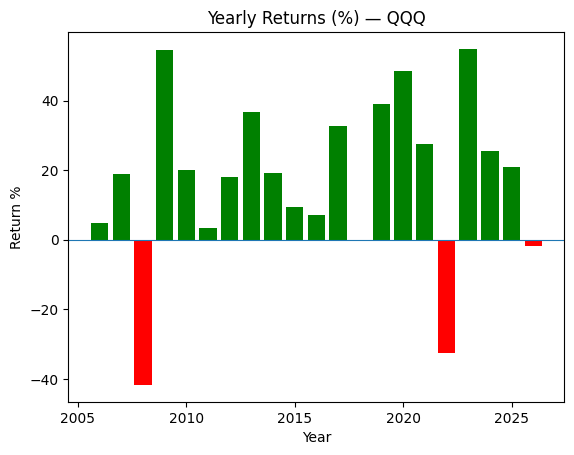


Monthly return table (%): Sentinel 11
Month     1      2     3     4      5     6     7      8      9      10     11    12
Year                                                                                
2006   -0.01  -0.20  0.07 -0.05  -0.22 -0.00  0.07   0.09   0.11   0.12   0.15 -0.08
2007   -4.27  -4.25 -0.06  8.61   3.93  5.84  6.73   1.20   3.00   1.54  -1.21  0.03
2008   -3.83  -0.95 -0.81  1.04   1.16 -5.58 -2.71   1.34  -1.38  -0.23  -0.12  0.06
2009    0.00  -0.01  0.09  0.29   0.01 -0.11  0.33   0.22   0.31  -0.04   1.80  2.53
2010  -11.61   0.12  9.78  5.02  -2.27 -0.83 -0.05  -2.08   5.82   3.91   3.39  1.76
2011   10.79   6.29 -2.29 -1.62   1.42 -0.70 -0.70  -1.98  -0.74   0.47  -1.44  0.69
2012    2.92   9.95  5.34 -4.01  -7.52  1.96  0.52   1.37   1.76  -8.33   2.23  1.13
2013   15.93  -0.02 -1.18  3.27   3.26 -6.37  6.95   5.70   8.90  -1.17   1.59  3.52
2014   -2.62   9.41 -2.71 -0.95   0.84  1.26 -1.16   6.66   0.74  -0.80   1.76 -1.75
2015    0.18   3.98 -2.32 

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import json
import hashlib
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

# =========================
# CONFIG
# =========================

@dataclass
class CostsConfig:
    commission: float = 0.001
    slippage: float = 0.0002
    apply_slippage: bool = True

@dataclass
class Tech11Config:
    capital_initial: float = 100000.0
    start: str = "2006-01-01"
    end: str = "2026-02-20"
    trading_days: int = 252
    rf_annual: float = 0.0

    # Universo Tech
    universe: Tuple[str, ...] = ('AAPL','MSFT','NVDA','GOOGL','AMZN','META','AVGO','ASML','TSM','ADBE','NFLX','AMD')

    # Benchmarks / régimen
    bench_qqq: str = "QQQ"
    bench_spy: str = "SPY"
    bench_ndx: str = "^NDX"   # opcional (puede ser price index)

    # Cache
    cache_dir: str = "data_cache"

    # Rebalance
    rebalance_freq: str = "W-FRI"
    top_k: int = 5

    # -------- Self-tuning ER --------
    er_window: int = 30  # para ER
    # Trend ensembles
    spans_short: Tuple[int, ...] = (42, 84, 126)
    spans_long:  Tuple[int, ...] = (63, 126, 252)
    # Momentum windows
    mom_windows: Tuple[int, ...] = (63, 126, 252)
    # Relative strength windows
    rel_windows: Tuple[int, ...] = (63, 126)

    # Score weights (suman 1)
    w_trend: float = 0.50
    w_mom: float = 0.30
    w_rel: float = 0.20

    burn_in: int = 260  # suficiente para MA200, ATR, etc.

    # -------- HRP --------
    hrp_window: int = 252
    weight_cap: float = 0.45  # permite concentración controlada

    # -------- ATR Chandelier Exit --------
    atr_window: int = 14
    k_base: float = 2.6
    k_er_gain: float = 1.2        # + con ER
    k_regime_gain: float = 0.6    # + en risk-on, - en crisis via state
    stop_on: bool = True
    allow_reentry: bool = True

    # -------- Regime (3 estados) --------
    regime_use: bool = True
    ma_fast: int = 50
    ma_slow: int = 200
    crisis_dd_threshold: float = 0.20
    crisis_vol_threshold: float = 0.35
    crisis_min_days: int = 5
    scale_risk_on: float = 1.00
    scale_caution: float = 0.85
    scale_crisis: float = 0.05

    # -------- Turbulence & liquidity filter --------
    turb_window: int = 63
    illiq_window: int = 21
    turb_sigmoid_a: float = 1.2
    turb_sigmoid_b: float = 0.5
    turb_scale_min: float = 0.35

    # -------- Vol targeting (growth-grade) --------
    vol_target_on: bool = True
    vol_target_ann: float = 0.22
    port_vol_window: int = 63
    max_exposure: float = 1.0
    min_exposure: float = 0.0  # permite “no operabilidad” real en crisis

    # -------- Validación --------
    cv_train_years: int = 8
    cv_test_years: int = 2
    purge_days: int = 10
    embargo_days: int = 5
    dd_cap_cv: float = -0.40
    lambda_dd: float = 1.5
    lambda_var: float = 0.6
    min_splits: int = 4

STRESS_EPISODES = {
    "GFC_2008": ("2008-01-01", "2009-06-30"),
    "EURO_2011": ("2011-07-01", "2011-12-31"),
    "Q4_2018": ("2018-10-01", "2018-12-31"),
    "COVID_2020": ("2020-02-15", "2020-06-30"),
    "RATES_2022": ("2022-01-01", "2022-12-31"),
}

# =========================
# HELPERS
# =========================

def _ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)

def _hash_key(obj: dict) -> str:
    s = json.dumps(obj, sort_keys=True).encode("utf-8")
    return hashlib.md5(s).hexdigest()

def to_1d_series(x, name="x") -> pd.Series:
    if x is None:
        return pd.Series(dtype=float, name=name)
    if isinstance(x, pd.Series):
        return x.rename(name)
    if isinstance(x, pd.DataFrame):
        if x.shape[1] == 0:
            return pd.Series(dtype=float, name=name)
        return x.iloc[:, 0].rename(name)
    arr = np.asarray(x)
    if arr.ndim == 2 and arr.shape[1] == 1:
        arr = arr.reshape(-1)
    return pd.Series(arr, name=name)

def safe_zscore(s: pd.Series, window: int = 252) -> pd.Series:
    m = s.rolling(window).mean()
    sd = s.rolling(window).std().replace(0, np.nan)
    z = (s - m) / sd
    return z.replace([np.inf, -np.inf], np.nan).fillna(0.0)

# =========================
# DATA: OHLCV with cache
# =========================

def download_ohlcv_cached(tickers: List[str], start: str, end: str, cache_dir: str) -> Dict[str, pd.DataFrame]:
    """
    Descarga OHLCV (auto_adjust=True) para tickers.
    Devuelve dict: close/high/low/volume DataFrames.
    """
    _ensure_dir(cache_dir)
    key = _hash_key({"tickers": tickers, "start": start, "end": end, "auto_adjust": True, "ohlcv": True})
    path = os.path.join(cache_dir, f"ohlcv_{key}.pkl")

    if os.path.exists(path):
        return pd.read_pickle(path)

    raw = yf.download(tickers, start=start, end=end, auto_adjust=True, group_by="ticker", progress=False)
    idx = pd.bdate_range(start=start, end=end)

    close = pd.DataFrame(index=idx)
    high  = pd.DataFrame(index=idx)
    low   = pd.DataFrame(index=idx)
    vol   = pd.DataFrame(index=idx)

    for t in tickers:
        try:
            if isinstance(raw.columns, pd.MultiIndex):
                # yfinance suele devolver (Ticker, Field)
                c = raw[(t, "Close")] if (t, "Close") in raw.columns else None
                h = raw[(t, "High")]  if (t, "High")  in raw.columns else None
                l = raw[(t, "Low")]   if (t, "Low")   in raw.columns else None
                v = raw[(t, "Volume")]if (t, "Volume")in raw.columns else None
            else:
                # single ticker
                c = raw["Close"] if "Close" in raw.columns else None
                h = raw["High"]  if "High"  in raw.columns else None
                l = raw["Low"]   if "Low"   in raw.columns else None
                v = raw["Volume"]if "Volume"in raw.columns else None

            if c is None:
                continue

            close[t] = pd.Series(c).reindex(idx).ffill(limit=5)
            high[t]  = pd.Series(h).reindex(idx).ffill(limit=5) if h is not None else close[t]
            low[t]   = pd.Series(l).reindex(idx).ffill(limit=5) if l is not None else close[t]
            vol[t]   = pd.Series(v).reindex(idx).ffill(limit=5) if v is not None else np.nan

        except Exception:
            continue

    out = {
        "close": close.dropna(how="all"),
        "high":  high.dropna(how="all"),
        "low":   low.dropna(how="all"),
        "volume":vol.dropna(how="all"),
    }
    pd.to_pickle(out, path)
    return out

def align_returns_no_fill(price_series: pd.Series, idx: pd.DatetimeIndex) -> pd.Series:
    p = to_1d_series(price_series, "p").reindex(idx)
    return p.pct_change()

# =========================
# HRP (with scipy fallback)
# =========================

def hrp_weights(returns: pd.DataFrame) -> pd.Series:
    """
    HRP clásico (Lopez de Prado) con fallback a inverse-variance si scipy no está.
    """
    try:
        from scipy.cluster.hierarchy import linkage
        from scipy.spatial.distance import squareform
    except Exception:
        # fallback: inverse variance
        cov = returns.cov()
        iv = 1.0 / np.diag(cov)
        w = iv / iv.sum()
        return pd.Series(w, index=returns.columns)

    cov = returns.cov()
    corr = returns.corr()

    # distance
    dist = np.sqrt(0.5 * (1 - corr)).clip(0, 1)
    dist_cond = squareform(dist.values, checks=False)

    link = linkage(dist_cond, method="single")

    # quasi-diagonalize
    def _get_quasi_diag(linkage_matrix):
        linkage_matrix = linkage_matrix.astype(int)
        sort_ix = pd.Series([linkage_matrix[-1, 0], linkage_matrix[-1, 1]])
        num_items = linkage_matrix[-1, 3]

        while sort_ix.max() >= num_items:
            sort_ix.index = range(0, sort_ix.shape[0] * 2, 2)
            df0 = sort_ix[sort_ix >= num_items]
            i = df0.index
            j = df0.values - num_items
            sort_ix[i] = linkage_matrix[j, 0]
            df1 = pd.Series(linkage_matrix[j, 1], index=i + 1)
            sort_ix = pd.concat([sort_ix, df1]).sort_index()
            sort_ix.index = range(sort_ix.shape[0])
        return sort_ix.tolist()

    sort_ix = _get_quasi_diag(link)
    ordered = corr.index[sort_ix]

    cov_ = cov.loc[ordered, ordered]

    # recursive bisection
    w = pd.Series(1.0, index=ordered)

    def _cluster_var(cov_mat, items):
        sub = cov_mat.loc[items, items]
        iv = 1.0 / np.diag(sub)
        iv = iv / iv.sum()
        return float(iv.T @ sub.values @ iv)

    clusters = [ordered.tolist()]
    while len(clusters) > 0:
        clusters = [c for c in clusters if len(c) > 1]
        if len(clusters) == 0:
            break
        new_clusters = []
        for c in clusters:
            split = len(c) // 2
            c1 = c[:split]
            c2 = c[split:]
            var1 = _cluster_var(cov_, c1)
            var2 = _cluster_var(cov_, c2)
            alpha = 1.0 - var1 / (var1 + var2) if (var1 + var2) != 0 else 0.5
            w[c1] *= alpha
            w[c2] *= (1 - alpha)
            new_clusters += [c1, c2]
        clusters = new_clusters

    w = w / w.sum()
    return w

# =========================
# ER self-tuning + scores
# =========================

def efficiency_ratio(price: pd.Series, n: int) -> pd.Series:
    p = price
    change = (p - p.shift(n)).abs()
    vol = p.diff().abs().rolling(n).sum()
    er = (change / vol).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return er.clip(0, 1)

def trend_vote(price: pd.Series, spans: Tuple[int, ...]) -> pd.Series:
    votes = []
    for s in spans:
        ema = price.ewm(span=s, adjust=False).mean().shift(1)
        v = ((price > ema) & price.notna() & ema.notna()).astype(float)
        votes.append(v)
    return sum(votes) / len(votes)

def compute_scores(close: pd.DataFrame, qqq_close: pd.Series, cfg: Tech11Config) -> pd.DataFrame:
    idx = close.index
    scores = pd.DataFrame(index=idx, columns=close.columns, dtype=float)

    qqq = to_1d_series(qqq_close, "QQQ").reindex(idx).ffill()
    for t in close.columns:
        p = close[t].reindex(idx).ffill()

        # ER for self-tuning mix
        er = efficiency_ratio(p, cfg.er_window)
        er_star = ((er - 0.10) / 0.40).clip(0, 1)  # escala estable

        # Trend: mezcla short/long
        tr_short = trend_vote(p, cfg.spans_short)
        tr_long  = trend_vote(p, cfg.spans_long)
        trend = er_star * tr_short + (1 - er_star) * tr_long

        # Momentum (multi-window, usando precios, shift 1)
        moms = []
        for w in cfg.mom_windows:
            moms.append((p / p.shift(w) - 1.0).shift(1))
        mom_raw = sum(moms) / len(moms)
        mom = ((mom_raw.clip(-1, 1) + 1.0) / 2.0)

        # Relative strength vs QQQ (rápido y correcto)
        rels = []
        for w in cfg.rel_windows:
            a = (p / p.shift(w) - 1.0).shift(1)
            b = (qqq / qqq.shift(w) - 1.0).shift(1)
            rels.append(a - b)
        rel_raw = sum(rels) / len(rels)
        rel = ((rel_raw.clip(-1, 1) + 1.0) / 2.0)

        s = cfg.w_trend * trend + cfg.w_mom * mom + cfg.w_rel * rel
        s.iloc[:cfg.burn_in] = 0.0
        scores[t] = s.fillna(0.0)

    return scores.fillna(0.0)

def select_topk(scores: pd.DataFrame, k: int, freq: str) -> pd.DataFrame:
    idx = scores.index
    reb_dates = scores.resample(freq).last().index
    mask = pd.DataFrame(0.0, index=idx, columns=scores.columns)
    last = np.zeros(scores.shape[1])
    cols = list(scores.columns)
    for dt in idx:
        if dt in reb_dates:
            row = scores.loc[dt].values
            order = np.argsort(-row)
            top = set(order[:k])
            last = np.array([1.0 if i in top else 0.0 for i in range(len(cols))], dtype=float)
        mask.loc[dt] = last
    return mask.fillna(0.0)

# =========================
# ATR + Chandelier Exit
# =========================

def atr_true(high: pd.Series, low: pd.Series, close: pd.Series, window: int) -> pd.Series:
    prev = close.shift(1)
    tr = pd.concat([
        (high - low).abs(),
        (high - prev).abs(),
        (low - prev).abs()
    ], axis=1).max(axis=1)
    return tr.rolling(window).mean()

def compute_k_dynamic(er_star: pd.Series, regime_state: pd.Series, cfg: Tech11Config) -> pd.Series:
    """
    k = k_base + k_er_gain*ER* + k_regime_gain*(state-1)
    state: 2=risk_on, 1=caution, 0=crisis
    """
    return (cfg.k_base + cfg.k_er_gain * er_star + cfg.k_regime_gain * (regime_state - 1.0)).clip(1.6, 4.5)

def apply_chandelier_stop(weights: pd.DataFrame,
                          close: pd.DataFrame, high: pd.DataFrame, low: pd.DataFrame,
                          qqq_close: pd.Series,
                          cfg: Tech11Config,
                          regime_state: pd.Series) -> pd.DataFrame:
    """
    Aplica Chandelier Exit por activo:
    stop = max_since_entry - k*ATR
    - Bloquea hasta próximo rebalance si allow_reentry=False
    - Si allow_reentry=True, permite reentrada en rebalance.
    """
    if not cfg.stop_on:
        return weights

    out = weights.copy()
    idx = out.index
    reb_dates = out.resample(cfg.rebalance_freq).last().index

    # precompute ER* por activo para k dinámico
    for t in out.columns:
        p = close[t].reindex(idx).ffill()
        er = efficiency_ratio(p, cfg.er_window)
        er_star = ((er - 0.10) / 0.40).clip(0, 1)

        atr = atr_true(high[t].reindex(idx).ffill(),
                       low[t].reindex(idx).ffill(),
                       close[t].reindex(idx).ffill(),
                       cfg.atr_window).fillna(method="bfill").fillna(0.0)

        k_t = compute_k_dynamic(er_star, regime_state.reindex(idx).fillna(1.0), cfg)

        wt = out[t].values
        in_pos = False
        maxp = np.nan
        stopped = False

        for i, dt in enumerate(idx):
            if dt in reb_dates and cfg.allow_reentry:
                stopped = False  # re-habilita

            if wt[i] <= 0:
                in_pos = False
                maxp = np.nan
                continue

            if stopped and not cfg.allow_reentry:
                wt[i] = 0.0
                continue
            if stopped and cfg.allow_reentry:
                wt[i] = 0.0
                continue

            if not in_pos:
                in_pos = True
                maxp = float(p.iloc[i])
            else:
                maxp = max(maxp, float(p.iloc[i]))

            stop_level = maxp - float(k_t.iloc[i]) * float(atr.iloc[i])
            if float(p.iloc[i]) < stop_level:
                wt[i] = 0.0
                stopped = True
                in_pos = False
                maxp = np.nan

        out[t] = wt

    denom = out.sum(axis=1).replace(0, np.nan)
    out = out.div(denom, axis=0).fillna(0.0)
    return out

# =========================
# Regime + Turbulence
# =========================

def compute_regime(qqq_close: pd.Series, cfg: Tech11Config) -> Tuple[pd.Series, pd.Series]:
    """
    Retorna:
    - regime_scale (1.0 / 0.85 / 0.05)
    - regime_state (2 risk_on, 1 caution, 0 crisis)
    """
    p = to_1d_series(qqq_close, "QQQ").ffill()
    idx = p.index

    ma_f = p.ewm(span=cfg.ma_fast, adjust=False).mean()
    ma_s = p.ewm(span=cfg.ma_slow, adjust=False).mean()

    r = p.pct_change().fillna(0.0)
    vol = r.rolling(cfg.port_vol_window).std() * np.sqrt(cfg.trading_days)
    vol = vol.fillna(method="bfill").fillna(0.0)

    dd = p / p.cummax() - 1.0

    crisis_raw = ((dd <= -cfg.crisis_dd_threshold) | (vol >= cfg.crisis_vol_threshold)).astype(int)
    crisis = crisis_raw.rolling(cfg.crisis_min_days).mean().fillna(0.0) >= 0.8

    risk_on = (p > ma_s) & (ma_f >= ma_s)
    state = pd.Series(1.0, index=idx)  # caution default
    state[risk_on] = 2.0
    state[crisis] = 0.0

    scale = pd.Series(cfg.scale_caution, index=idx, dtype=float)
    scale[state == 2.0] = cfg.scale_risk_on
    scale[state == 0.0] = cfg.scale_crisis

    scale.iloc[:cfg.burn_in] = cfg.scale_crisis
    state.iloc[:cfg.burn_in] = 0.0
    return scale, state

def sector_pairwise_corr(returns: pd.DataFrame) -> pd.Series:
    # promedio de correlaciones pairwise (excluye diagonal)
    corr = returns.rolling(1).corr()  # placeholder; se recalcula abajo
    # más eficiente:
    out = []
    idx = returns.index
    for t in idx:
        pass
    return pd.Series(dtype=float)

def compute_turbulence(close: pd.DataFrame, volume: pd.DataFrame, qqq_close: pd.Series, cfg: Tech11Config) -> pd.Series:
    """
    TURB = z(vol_QQQ) + z(avg_corr_sector) + z(avg_illiq)
    scale_turb = sigmoid -> [turb_scale_min, 1]
    """
    idx = close.index
    qqq = to_1d_series(qqq_close, "QQQ").reindex(idx).ffill()
    qqq_r = qqq.pct_change().fillna(0.0)
    vol_q = (qqq_r.rolling(cfg.turb_window).std() * np.sqrt(cfg.trading_days)).fillna(0.0)

    rets = close.pct_change().fillna(0.0)
    # avg pairwise corr (rolling)
    # compute corr on rolling window by sampling end-of-window
    avg_corr = pd.Series(0.0, index=idx)
    w = cfg.turb_window
    for i in range(len(idx)):
        if i < w:
            continue
        sub = rets.iloc[i-w+1:i+1]
        c = sub.corr().values
        n = c.shape[0]
        if n <= 1:
            avg_corr.iloc[i] = 0.0
        else:
            avg_corr.iloc[i] = (c.sum() - n) / (n*(n-1))  # mean off-diagonal
    avg_corr = avg_corr.fillna(0.0)

    # Amihud illiq
    dv = (close * volume).replace(0, np.nan)
    illiq = (rets.abs() / dv).replace([np.inf, -np.inf], np.nan)
    illiq_avg = illiq.rolling(cfg.illiq_window).mean().mean(axis=1).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    turb = safe_zscore(vol_q, 252) + safe_zscore(avg_corr, 252) + safe_zscore(illiq_avg, 252)

    # sigmoid scale
    a = cfg.turb_sigmoid_a
    b = cfg.turb_sigmoid_b
    s = 1.0 / (1.0 + np.exp(a * (turb - b)))
    s = pd.Series(s, index=idx).clip(lower=cfg.turb_scale_min, upper=1.0)
    s.iloc[:cfg.burn_in] = cfg.turb_scale_min
    return s

# =========================
# Vol target (portfolio)
# =========================

def vol_target_scale(port_gross: pd.Series, cfg: Tech11Config) -> pd.Series:
    if not cfg.vol_target_on:
        return pd.Series(1.0, index=port_gross.index)
    r = to_1d_series(port_gross, "r").fillna(0.0)
    vol = r.rolling(cfg.port_vol_window).std() * np.sqrt(cfg.trading_days)
    scale = (cfg.vol_target_ann / vol).replace([np.inf, -np.inf], np.nan).fillna(1.0)
    scale = scale.clip(lower=cfg.min_exposure, upper=cfg.max_exposure)
    return scale

# =========================
# Backtest Sentinel 11
# =========================

def backtest_tech11(ohlcv: Dict[str, pd.DataFrame], cfg: Tech11Config, costs: CostsConfig) -> Dict:
    close = ohlcv["close"][list(cfg.universe)].copy()
    high  = ohlcv["high"][list(cfg.universe)].copy()
    low   = ohlcv["low"][list(cfg.universe)].copy()
    vol   = ohlcv["volume"][list(cfg.universe)].copy()

    idx = close.index

    qqq = ohlcv["close"][cfg.bench_qqq].reindex(idx).ffill()
    spy = ohlcv["close"][cfg.bench_spy].reindex(idx).ffill()
    ndx = ohlcv["close"][cfg.bench_ndx].reindex(idx).ffill() if cfg.bench_ndx in ohlcv["close"].columns else None

    # Regime + state
    reg_scale, reg_state = compute_regime(qqq, cfg) if cfg.regime_use else (pd.Series(1.0, index=idx), pd.Series(2.0, index=idx))

    # Turbulence scale
    turb_scale = compute_turbulence(close, vol, qqq, cfg)

    # Scores + TopK
    scores = compute_scores(close, qqq, cfg)
    active_mask = select_topk(scores, cfg.top_k, cfg.rebalance_freq)

    # Build HRP weights on rebalance dates, hold between
    reb_dates = close.resample(cfg.rebalance_freq).last().index
    w = pd.DataFrame(0.0, index=idx, columns=close.columns)

    rets = close.pct_change().fillna(0.0)

    last_w = pd.Series(0.0, index=close.columns)
    for dt in idx:
        if dt in reb_dates:
            sel = active_mask.loc[dt]
            names = sel[sel > 0].index.tolist()
            if len(names) == 0:
                last_w = pd.Series(0.0, index=close.columns)
            elif len(names) == 1:
                last_w = pd.Series(0.0, index=close.columns)
                last_w[names[0]] = 1.0
            else:
                lookback = rets.loc[:dt].tail(cfg.hrp_window)
                sub = lookback[names].dropna()
                if len(sub) < 60:
                    # fallback inverse variance
                    cov = sub.cov()
                    iv = 1.0 / np.diag(cov)
                    ww = iv / iv.sum()
                    ww = pd.Series(ww, index=names)
                else:
                    ww = hrp_weights(sub)

                # cap weights to allow concentration but avoid single name dominating
                ww = ww.clip(upper=cfg.weight_cap)
                ww = ww / ww.sum()

                last_w = pd.Series(0.0, index=close.columns)
                last_w[names] = ww.values
        w.loc[dt] = last_w.values

    # Chandelier stop on weights
    w_stopped = apply_chandelier_stop(w, close, high, low, qqq, cfg, reg_state)

    # Portfolio gross returns (no look-ahead: weights shift)
    port_gross = (w_stopped.shift(1).fillna(0.0) * rets).sum(axis=1)

    # Vol target
    vol_scale = vol_target_scale(port_gross, cfg)

    # Combine scales
    total_scale = (reg_scale * turb_scale * vol_scale).clip(lower=0.0, upper=cfg.max_exposure)

    w_scaled = w_stopped.mul(total_scale, axis=0)

    # Costs via turnover on scaled weights
    def _turnover(df):
        dw = df.diff().abs().fillna(0.0)
        return 0.5 * dw.sum(axis=1)

    to = _turnover(w_scaled)
    tc = to * (costs.commission + (costs.slippage if costs.apply_slippage else 0.0))
    port_net = (port_gross * total_scale - tc).replace([np.inf, -np.inf], 0.0).fillna(0.0)

    equity = cfg.capital_initial * (1.0 + port_net).cumprod()
    exposure = w_scaled.abs().sum(axis=1).clip(0, cfg.max_exposure)

    # Bench returns/equity
    qqq_r = qqq.pct_change().fillna(0.0)
    spy_r = spy.pct_change().fillna(0.0)
    qqq_eq = cfg.capital_initial * (1.0 + qqq_r).cumprod()
    spy_eq = cfg.capital_initial * (1.0 + spy_r).cumprod()
    if ndx is not None:
        ndx_r = ndx.pct_change().fillna(0.0)
        ndx_eq = cfg.capital_initial * (1.0 + ndx_r).cumprod()
    else:
        ndx_r = None
        ndx_eq = None

    return {
        "returns_net": port_net,
        "equity": equity,
        "exposure": exposure,
        "turnover": to,
        "weights": w_stopped,
        "weights_scaled": w_scaled,
        "scores": scores,
        "active_mask": active_mask,
        "reg_scale": reg_scale,
        "reg_state": reg_state,
        "turb_scale": turb_scale,
        "vol_scale": vol_scale,
        "total_scale": total_scale,
        "bench": {
            "QQQ_r": qqq_r, "QQQ_eq": qqq_eq,
            "SPY_r": spy_r, "SPY_eq": spy_eq,
            "NDX_r": ndx_r, "NDX_eq": ndx_eq
        }
    }

# =========================
# Reports & simulations
# =========================

def total_return(r: pd.Series) -> float:
    r = to_1d_series(r, "r").dropna()
    return float((1.0 + r).prod() - 1.0) if len(r) else 0.0

def cagr(r: pd.Series, td=252) -> float:
    r = to_1d_series(r, "r").dropna()
    if len(r) == 0:
        return 0.0
    tr = (1.0 + r).prod() - 1.0
    return float((1.0 + tr) ** (td / len(r)) - 1.0)

def ann_vol(r: pd.Series, td=252) -> float:
    r = to_1d_series(r, "r").dropna()
    sd = r.std(ddof=1)
    return float(sd * np.sqrt(td)) if sd == sd else np.nan

def sharpe(r: pd.Series, rf_ann=0.0, td=252) -> float:
    r = to_1d_series(r, "r").dropna()
    rf_d = (1.0 + rf_ann) ** (1.0 / td) - 1.0
    ex = r - rf_d
    sd = ex.std(ddof=1)
    return float(np.sqrt(td) * ex.mean() / sd) if sd and sd == sd else 0.0

def sortino(r: pd.Series, rf_ann=0.0, td=252) -> float:
    r = to_1d_series(r, "r").dropna()
    rf_d = (1.0 + rf_ann) ** (1.0 / td) - 1.0
    ex = r - rf_d
    dn = ex.copy()
    dn[dn > 0] = 0
    sd = dn.std(ddof=1)
    return float(np.sqrt(td) * ex.mean() / sd) if sd and sd == sd else 0.0

def max_dd(eq: pd.Series) -> float:
    eq = to_1d_series(eq, "eq").dropna()
    if len(eq) == 0:
        return 0.0
    dd = eq / eq.cummax() - 1.0
    return float(dd.min())

def calmar(r: pd.Series, eq: pd.Series, td=252) -> float:
    a = cagr(r, td)
    d = max_dd(eq)
    return float(a / abs(d)) if d != 0 else np.inf

def cvar(r: pd.Series, alpha=0.05) -> float:
    x = to_1d_series(r, "r").dropna().values
    if len(x) == 0:
        return np.nan
    q = np.quantile(x, alpha)
    tail = x[x <= q]
    return float(tail.mean()) if len(tail) else float(q)

def summarize_series(r: pd.Series, eq: pd.Series, exposure: Optional[pd.Series], turnover: Optional[pd.Series], cfg: Tech11Config) -> Dict:
    r = to_1d_series(r, "r").replace([np.inf, -np.inf], np.nan).dropna()
    eq = to_1d_series(eq, "eq").dropna()
    exp = to_1d_series(exposure, "exp").reindex(r.index).fillna(0.0) if exposure is not None else pd.Series(np.nan, index=r.index)
    to = to_1d_series(turnover, "to").reindex(r.index).fillna(0.0) if turnover is not None else pd.Series(0.0, index=r.index)
    return {
        "FinalEquity": float(eq.iloc[-1]) if len(eq) else np.nan,
        "TotalReturn": total_return(r),
        "CAGR": cagr(r, cfg.trading_days),
        "AnnVol": ann_vol(r, cfg.trading_days),
        "Sharpe": sharpe(r, cfg.rf_annual, cfg.trading_days),
        "Sortino": sortino(r, cfg.rf_annual, cfg.trading_days),
        "MaxDD": max_dd(eq),
        "Calmar": calmar(r, eq, cfg.trading_days),
        "CVaR_5": cvar(r, 0.05),
        "AvgExposure": float(exp.mean()) if exp is not None else np.nan,
        "TimeInMkt": float((exp > 0).mean()) if exp is not None else np.nan,
        "TurnoverAnn": float(to.sum() * (cfg.trading_days / len(r))) if len(r) else 0.0,
        "Days": int(len(r)),
    }

def moving_block_bootstrap(r: pd.Series, block=20, n_samples=800, seed=42) -> Dict:
    rng = np.random.default_rng(seed)
    x = to_1d_series(r, "r").replace([np.inf, -np.inf], np.nan).dropna().values
    T = len(x)
    if T < block * 5:
        return {"dd_p50": np.nan, "dd_p95": np.nan, "ruin_prob_50dd": np.nan}
    dds = []
    for _ in range(n_samples):
        starts = rng.integers(0, T - block, size=int(np.ceil(T / block)))
        sample = np.concatenate([x[s:s + block] for s in starts])[:T]
        eq = (1.0 + sample).cumprod()
        peak = np.maximum.accumulate(eq)
        dds.append(np.min(eq / peak - 1.0))
    dds = np.array(dds)
    return {
        "dd_p50": float(np.quantile(dds, 0.50)),
        "dd_p95": float(np.quantile(dds, 0.05)),
        "ruin_prob_50dd": float(np.mean(dds < -0.5)) * 100.0
    }

def stress_report(full_res: Dict, episodes: Dict[str, Tuple[str, str]], cfg: Tech11Config) -> pd.DataFrame:
    r = full_res["returns_net"]
    eq = full_res["equity"]
    exp = full_res["exposure"]
    out = []
    for name, (a, b) in episodes.items():
        sub_idx = r.loc[a:b].index
        if len(sub_idx) < 40:
            continue
        rr = r.loc[sub_idx]
        ee = cfg.capital_initial * (1.0 + rr).cumprod()
        ss = summarize_series(rr, ee, exp.loc[sub_idx], None, cfg)
        out.append({
            "Episode": name,
            "CAGR%": round(ss["CAGR"]*100, 2),
            "Sharpe": round(ss["Sharpe"], 3),
            "MaxDD%": round(ss["MaxDD"]*100, 2),
            "Calmar": round(ss["Calmar"], 3),
            "AvgExposure%": round(ss["AvgExposure"]*100, 1),
            "TimeInMkt%": round(ss["TimeInMkt"]*100, 1),
        })
    return pd.DataFrame(out)

# =========================
# PLOTS
# =========================

def plot_equity(curves: Dict[str, pd.Series], title: str):
    plt.figure()
    for k, s in curves.items():
        s = to_1d_series(s, k).dropna()
        if len(s):
            plt.plot(s.index, s.values, label=k)
    plt.title(title); plt.xlabel("Date"); plt.ylabel("Equity"); plt.legend(); plt.show()

def plot_drawdown(eq: pd.Series, title: str):
    eq = to_1d_series(eq, "eq").dropna()
    dd = eq / eq.cummax() - 1.0
    plt.figure()
    plt.plot(dd.index, dd.values)
    plt.title(title); plt.xlabel("Date"); plt.ylabel("Drawdown"); plt.show()

def plot_scales(res: Dict, title: str):
    exp = to_1d_series(res["exposure"], "exp").fillna(0)
    reg = to_1d_series(res["reg_scale"], "reg").fillna(0)
    turb = to_1d_series(res["turb_scale"], "turb").fillna(0)
    vol = to_1d_series(res["vol_scale"], "vol").fillna(0)
    tot = to_1d_series(res["total_scale"], "tot").fillna(0)

    plt.figure()
    plt.plot(exp.index, exp.values, label="Exposure")
    plt.plot(reg.index, reg.values, label="RegimeScale")
    plt.plot(turb.index, turb.values, label="TurbScale")
    plt.plot(vol.index, vol.values, label="VolScale")
    plt.plot(tot.index, tot.values, label="TotalScale")
    plt.title(title); plt.xlabel("Date"); plt.legend(); plt.show()

def plot_turnover(to: pd.Series, title: str):
    to = to_1d_series(to, "to").fillna(0)
    plt.figure()
    plt.plot(to.index, to.values)
    plt.title(title); plt.xlabel("Date"); plt.ylabel("Turnover"); plt.show()

def plot_rolling_metrics(r: pd.Series, title: str, window=126):
    r = to_1d_series(r, "r").replace([np.inf, -np.inf], np.nan).dropna()
    if len(r) < window * 2:
        return
    roll_sh = (r.rolling(window).mean() / r.rolling(window).std()).replace([np.inf, -np.inf], np.nan) * np.sqrt(252)
    roll_vol = r.rolling(window).std() * np.sqrt(252)
    plt.figure(); plt.plot(roll_sh.index, roll_sh.values); plt.title(f"Rolling Sharpe ({window}d) — {title}")
    plt.xlabel("Date"); plt.ylabel("Sharpe"); plt.show()
    plt.figure(); plt.plot(roll_vol.index, roll_vol.values); plt.title(f"Rolling Vol ({window}d) — {title}")
    plt.xlabel("Date"); plt.ylabel("AnnVol"); plt.show()

def plot_year_bars(r: pd.Series, title: str):
    yr = (1.0 + r.fillna(0.0)).resample("Y").prod() - 1.0
    if len(yr) == 0:
        return
    df = pd.DataFrame({"Year": yr.index.year, "Ret%": yr.values * 100})
    colors = ["green" if x >= 0 else "red" for x in df["Ret%"]]
    plt.figure()
    plt.bar(df["Year"], df["Ret%"], color=colors)
    plt.axhline(0, linewidth=0.8)
    plt.title(f"Yearly Returns (%) — {title}")
    plt.xlabel("Year"); plt.ylabel("Return %")
    plt.show()

def print_monthly_table(r: pd.Series, title: str):
    mr = (1.0 + r.fillna(0.0)).resample("M").prod() - 1.0
    if len(mr) == 0:
        return
    df = pd.DataFrame({"date": mr.index, "ret": mr.values})
    df["Year"] = df["date"].dt.year
    df["Month"] = df["date"].dt.month
    piv = df.pivot_table(index="Year", columns="Month", values="ret", aggfunc="mean") * 100
    print("\nMonthly return table (%):", title)
    print(piv.round(2).to_string())

# =========================
# RUN
# =========================

def run_sentinel11(make_plots: bool = True):
    cfg = Tech11Config()
    costs = CostsConfig()

    tickers = list(cfg.universe) + [cfg.bench_qqq, cfg.bench_spy, cfg.bench_ndx]
    ohlcv = download_ohlcv_cached(tickers, cfg.start, cfg.end, cfg.cache_dir)

    # Full backtest
    res = backtest_tech11(ohlcv, cfg, costs)

    # Bench summaries
    qqq_r = res["bench"]["QQQ_r"]; qqq_eq = res["bench"]["QQQ_eq"]
    spy_r = res["bench"]["SPY_r"]; spy_eq = res["bench"]["SPY_eq"]
    ndx_r = res["bench"]["NDX_r"]; ndx_eq = res["bench"]["NDX_eq"]

    # Buy&Hold tech
    close = ohlcv["close"][list(cfg.universe)]
    bh_r = close.pct_change().fillna(0.0).mean(axis=1)
    bh_eq = cfg.capital_initial * (1.0 + bh_r).cumprod()

    s_sent = summarize_series(res["returns_net"], res["equity"], res["exposure"], res["turnover"], cfg)
    s_bh   = summarize_series(bh_r, bh_eq, pd.Series(1.0, index=bh_r.index), None, cfg)
    s_qqq  = summarize_series(qqq_r, qqq_eq, pd.Series(1.0, index=qqq_r.index), None, cfg)
    s_spy  = summarize_series(spy_r, spy_eq, pd.Series(1.0, index=spy_r.index), None, cfg)
    s_ndx  = summarize_series(ndx_r, ndx_eq, pd.Series(1.0, index=ndx_r.index), None, cfg) if ndx_r is not None else None

    def row(name, s):
        return {
            "Model": name,
            "FinalEq": round(s["FinalEquity"], 2),
            "Total%": round(s["TotalReturn"]*100, 2),
            "CAGR%": round(s["CAGR"]*100, 2),
            "Vol%": round(s["AnnVol"]*100, 2) if s["AnnVol"] == s["AnnVol"] else np.nan,
            "Sharpe": round(s["Sharpe"], 3),
            "Sortino": round(s["Sortino"], 3),
            "MaxDD%": round(s["MaxDD"]*100, 2),
            "Calmar": round(s["Calmar"], 3),
            "AvgExp%": round(s["AvgExposure"]*100, 1) if s["AvgExposure"] == s["AvgExposure"] else np.nan,
            "TimeInMkt%": round(s["TimeInMkt"]*100, 1) if s["TimeInMkt"] == s["TimeInMkt"] else np.nan,
            "TurnoverAnn": round(s["TurnoverAnn"], 2) if s["TurnoverAnn"] == s["TurnoverAnn"] else np.nan,
            "CVaR5%": round(s["CVaR_5"]*100, 3) if s["CVaR_5"] == s["CVaR_5"] else np.nan,
        }

    rows = [row("SENTINEL_11", s_sent), row("B&H_TECH", s_bh), row("QQQ", s_qqq), row("SPY", s_spy)]
    if s_ndx is not None:
        rows.append(row("^NDX", s_ndx))
    comp = pd.DataFrame(rows)

    print("\n" + "="*150)
    print("SENTINEL 11.0 — COMPARATIVO PRINCIPAL")
    print("="*150)
    print(comp.to_string(index=False))

    # Stress + Bootstrap
    stress = stress_report(res, STRESS_EPISODES, cfg)
    boot = moving_block_bootstrap(res["returns_net"], block=20, n_samples=800, seed=42)
    print("\n" + "="*150)
    print("STRESS EPISODES")
    print("="*150)
    print(stress.to_string(index=False))
    print("\nBOOTSTRAP blocks: DD p50={:.2f}%, DD p95(worst5%)={:.2f}%, P(DD<-50%)={:.2f}%".format(
        boot["dd_p50"]*100, boot["dd_p95"]*100, boot["ruin_prob_50dd"]
    ))

    # Exports
    os.makedirs("outputs", exist_ok=True)
    comp.to_csv("outputs/sentinel11_comparison.csv", index=False)
    stress.to_csv("outputs/sentinel11_stress.csv", index=False)

    # Plots
    if make_plots:
        plot_equity({
            "SENTINEL_11": res["equity"],
            "B&H_TECH": bh_eq,
            "QQQ": qqq_eq,
            "SPY": spy_eq,
            **({ "^NDX": ndx_eq } if ndx_eq is not None else {})
        }, "Equity Curves — Sentinel 11")

        plot_drawdown(res["equity"], "Drawdown (Underwater) — Sentinel 11")
        plot_scales(res, "Exposure & Scales (Regime/Turb/Vol/Total) — Sentinel 11")
        plot_turnover(res["turnover"], "Turnover (daily) — Sentinel 11")
        plot_rolling_metrics(res["returns_net"], "Sentinel 11", window=126)
        plot_year_bars(res["returns_net"], "Sentinel 11")
        plot_year_bars(qqq_r, "QQQ")
        print_monthly_table(res["returns_net"], "Sentinel 11")
        print_monthly_table(qqq_r, "QQQ")

    return {"comparison": comp, "stress": stress, "bootstrap": boot, "res": res}


if __name__ == "__main__":
    _ = run_sentinel11(make_plots=True)

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import json
import hashlib
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

# =========================
# CONFIG
# =========================

@dataclass
class CostsConfig:
    commission: float = 0.001
    slippage: float = 0.0002
    apply_slippage: bool = True

@dataclass
class Tech11Config:
    capital_initial: float = 100000.0
    start: str = "2006-01-01"
    end: str = "2026-02-20"
    trading_days: int = 252
    rf_annual: float = 0.0

    # Universo Tech
    universe: Tuple[str, ...] = ('AAPL','MSFT','NVDA','GOOGL','AMZN','META','AVGO','ASML','TSM','ADBE','NFLX','AMD')

    # Benchmarks / régimen
    bench_qqq: str = "QQQ"
    bench_spy: str = "SPY"
    bench_ndx: str = "^NDX"   # opcional (puede ser price index)

    # Cache
    cache_dir: str = "data_cache"

    # Rebalance
    rebalance_freq: str = "W-FRI"
    top_k: int = 5

    # -------- Self-tuning ER --------
    er_window: int = 30  # para ER
    # Trend ensembles
    spans_short: Tuple[int, ...] = (42, 84, 126)
    spans_long:  Tuple[int, ...] = (63, 126, 252)
    # Momentum windows
    mom_windows: Tuple[int, ...] = (63, 126, 252)
    # Relative strength windows
    rel_windows: Tuple[int, ...] = (63, 126)

    # Score weights (suman 1)
    w_trend: float = 0.50
    w_mom: float = 0.30
    w_rel: float = 0.20

    burn_in: int = 260  # suficiente para MA200, ATR, etc.

    # -------- HRP --------
    hrp_window: int = 252
    weight_cap: float = 0.45  # permite concentración controlada

    # -------- ATR Chandelier Exit --------
    atr_window: int = 14
    k_base: float = 2.6
    k_er_gain: float = 1.2        # + con ER
    k_regime_gain: float = 0.6    # + en risk-on, - en crisis via state
    stop_on: bool = True
    allow_reentry: bool = True

    # -------- Regime (3 estados) --------
    regime_use: bool = True
    ma_fast: int = 50
    ma_slow: int = 200
    crisis_dd_threshold: float = 0.20
    crisis_vol_threshold: float = 0.35
    crisis_min_days: int = 5
    scale_risk_on: float = 1.00
    scale_caution: float = 0.85
    scale_crisis: float = 0.05

    # -------- Turbulence & liquidity filter --------
    turb_window: int = 63
    illiq_window: int = 21
    turb_sigmoid_a: float = 1.2
    turb_sigmoid_b: float = 0.5
    turb_scale_min: float = 0.35

    # -------- Vol targeting (growth-grade) --------
    vol_target_on: bool = True
    vol_target_ann: float = 0.22
    port_vol_window: int = 63
    max_exposure: float = 1.0
    min_exposure: float = 0.0  # permite “no operabilidad” real en crisis

    # -------- Validación --------
    cv_train_years: int = 8
    cv_test_years: int = 2
    purge_days: int = 10
    embargo_days: int = 5
    dd_cap_cv: float = -0.40
    lambda_dd: float = 1.5
    lambda_var: float = 0.6
    min_splits: int = 4

STRESS_EPISODES = {
    "GFC_2008": ("2008-01-01", "2009-06-30"),
    "EURO_2011": ("2011-07-01", "2011-12-31"),
    "Q4_2018": ("2018-10-01", "2018-12-31"),
    "COVID_2020": ("2020-02-15", "2020-06-30"),
    "RATES_2022": ("2022-01-01", "2022-12-31"),
}

# =========================
# HELPERS
# =========================

def _ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)

def _hash_key(obj: dict) -> str:
    s = json.dumps(obj, sort_keys=True).encode("utf-8")
    return hashlib.md5(s).hexdigest()

def to_1d_series(x, name="x") -> pd.Series:
    if x is None:
        return pd.Series(dtype=float, name=name)
    if isinstance(x, pd.Series):
        return x.rename(name)
    if isinstance(x, pd.DataFrame):
        if x.shape[1] == 0:
            return pd.Series(dtype=float, name=name)
        return x.iloc[:, 0].rename(name)
    arr = np.asarray(x)
    if arr.ndim == 2 and arr.shape[1] == 1:
        arr = arr.reshape(-1)
    return pd.Series(arr, name=name)

def safe_zscore(s: pd.Series, window: int = 252) -> pd.Series:
    m = s.rolling(window).mean()
    sd = s.rolling(window).std().replace(0, np.nan)
    z = (s - m) / sd
    return z.replace([np.inf, -np.inf], np.nan).fillna(0.0)

# =========================
# DATA: OHLCV with cache
# =========================

def download_ohlcv_cached(tickers: List[str], start: str, end: str, cache_dir: str) -> Dict[str, pd.DataFrame]:
    """
    Descarga OHLCV (auto_adjust=True) para tickers.
    Devuelve dict: close/high/low/volume DataFrames.
    """
    _ensure_dir(cache_dir)
    key = _hash_key({"tickers": tickers, "start": start, "end": end, "auto_adjust": True, "ohlcv": True})
    path = os.path.join(cache_dir, f"ohlcv_{key}.pkl")

    if os.path.exists(path):
        return pd.read_pickle(path)

    raw = yf.download(tickers, start=start, end=end, auto_adjust=True, group_by="ticker", progress=False)
    idx = pd.bdate_range(start=start, end=end)

    close = pd.DataFrame(index=idx)
    high  = pd.DataFrame(index=idx)
    low   = pd.DataFrame(index=idx)
    vol   = pd.DataFrame(index=idx)

    for t in tickers:
        try:
            if isinstance(raw.columns, pd.MultiIndex):
                # yfinance suele devolver (Ticker, Field)
                c = raw[(t, "Close")] if (t, "Close") in raw.columns else None
                h = raw[(t, "High")]  if (t, "High")  in raw.columns else None
                l = raw[(t, "Low")]   if (t, "Low")   in raw.columns else None
                v = raw[(t, "Volume")]if (t, "Volume")in raw.columns else None
            else:
                # single ticker
                c = raw["Close"] if "Close" in raw.columns else None
                h = raw["High"]  if "High"  in raw.columns else None
                l = raw["Low"]   if "Low"   in raw.columns else None
                v = raw["Volume"]if "Volume"in raw.columns else None

            if c is None:
                continue

            close[t] = pd.Series(c).reindex(idx).ffill(limit=5)
            high[t]  = pd.Series(h).reindex(idx).ffill(limit=5) if h is not None else close[t]
            low[t]   = pd.Series(l).reindex(idx).ffill(limit=5) if l is not None else close[t]
            vol[t]   = pd.Series(v).reindex(idx).ffill(limit=5) if v is not None else np.nan

        except Exception:
            continue

    out = {
        "close": close.dropna(how="all"),
        "high":  high.dropna(how="all"),
        "low":   low.dropna(how="all"),
        "volume":vol.dropna(how="all"),
    }
    pd.to_pickle(out, path)
    return out

def align_returns_no_fill(price_series: pd.Series, idx: pd.DatetimeIndex) -> pd.Series:
    p = to_1d_series(price_series, "p").reindex(idx)
    return p.pct_change()

# =========================
# HRP (with scipy fallback)
# =========================

def hrp_weights(returns: pd.DataFrame) -> pd.Series:
    """
    HRP clásico (Lopez de Prado) con fallback a inverse-variance si scipy no está.
    """
    try:
        from scipy.cluster.hierarchy import linkage
        from scipy.spatial.distance import squareform
    except Exception:
        # fallback: inverse variance
        cov = returns.cov()
        iv = 1.0 / np.diag(cov)
        w = iv / iv.sum()
        return pd.Series(w, index=returns.columns)

    cov = returns.cov()
    corr = returns.corr()

    # distance
    dist = np.sqrt(0.5 * (1 - corr)).clip(0, 1)
    dist_cond = squareform(dist.values, checks=False)

    link = linkage(dist_cond, method="single")

    # quasi-diagonalize
    def _get_quasi_diag(linkage_matrix):
        linkage_matrix = linkage_matrix.astype(int)
        sort_ix = pd.Series([linkage_matrix[-1, 0], linkage_matrix[-1, 1]])
        num_items = linkage_matrix[-1, 3]

        while sort_ix.max() >= num_items:
            sort_ix.index = range(0, sort_ix.shape[0] * 2, 2)
            df0 = sort_ix[sort_ix >= num_items]
            i = df0.index
            j = df0.values - num_items
            sort_ix[i] = linkage_matrix[j, 0]
            df1 = pd.Series(linkage_matrix[j, 1], index=i + 1)
            sort_ix = pd.concat([sort_ix, df1]).sort_index()
            sort_ix.index = range(sort_ix.shape[0])
        return sort_ix.tolist()

    sort_ix = _get_quasi_diag(link)
    ordered = corr.index[sort_ix]

    cov_ = cov.loc[ordered, ordered]

    # recursive bisection
    w = pd.Series(1.0, index=ordered)

    def _cluster_var(cov_mat, items):
        sub = cov_mat.loc[items, items]
        iv = 1.0 / np.diag(sub)
        iv = iv / iv.sum()
        return float(iv.T @ sub.values @ iv)

    clusters = [ordered.tolist()]
    while len(clusters) > 0:
        clusters = [c for c in clusters if len(c) > 1]
        if len(clusters) == 0:
            break
        new_clusters = []
        for c in clusters:
            split = len(c) // 2
            c1 = c[:split]
            c2 = c[split:]
            var1 = _cluster_var(cov_, c1)
            var2 = _cluster_var(cov_, c2)
            alpha = 1.0 - var1 / (var1 + var2) if (var1 + var2) != 0 else 0.5
            w[c1] *= alpha
            w[c2] *= (1 - alpha)
            new_clusters += [c1, c2]
        clusters = new_clusters

    w = w / w.sum()
    return w

# =========================
# ER self-tuning + scores
# =========================

def efficiency_ratio(price: pd.Series, n: int) -> pd.Series:
    p = price
    change = (p - p.shift(n)).abs()
    vol = p.diff().abs().rolling(n).sum()
    er = (change / vol).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return er.clip(0, 1)

def trend_vote(price: pd.Series, spans: Tuple[int, ...]) -> pd.Series:
    votes = []
    for s in spans:
        ema = price.ewm(span=s, adjust=False).mean().shift(1)
        v = ((price > ema) & price.notna() & ema.notna()).astype(float)
        votes.append(v)
    return sum(votes) / len(votes)

def compute_scores(close: pd.DataFrame, qqq_close: pd.Series, cfg: Tech11Config) -> pd.DataFrame:
    idx = close.index
    scores = pd.DataFrame(index=idx, columns=close.columns, dtype=float)

    qqq = to_1d_series(qqq_close, "QQQ").reindex(idx).ffill()
    for t in close.columns:
        p = close[t].reindex(idx).ffill()

        # ER for self-tuning mix
        er = efficiency_ratio(p, cfg.er_window)
        er_star = ((er - 0.10) / 0.40).clip(0, 1)  # escala estable

        # Trend: mezcla short/long
        tr_short = trend_vote(p, cfg.spans_short)
        tr_long  = trend_vote(p, cfg.spans_long)
        trend = er_star * tr_short + (1 - er_star) * tr_long

        # Momentum (multi-window, usando precios, shift 1)
        moms = []
        for w in cfg.mom_windows:
            moms.append((p / p.shift(w) - 1.0).shift(1))
        mom_raw = sum(moms) / len(moms)
        mom = ((mom_raw.clip(-1, 1) + 1.0) / 2.0)

        # Relative strength vs QQQ (rápido y correcto)
        rels = []
        for w in cfg.rel_windows:
            a = (p / p.shift(w) - 1.0).shift(1)
            b = (qqq / qqq.shift(w) - 1.0).shift(1)
            rels.append(a - b)
        rel_raw = sum(rels) / len(rels)
        rel = ((rel_raw.clip(-1, 1) + 1.0) / 2.0)

        s = cfg.w_trend * trend + cfg.w_mom * mom + cfg.w_rel * rel
        s.iloc[:cfg.burn_in] = 0.0
        scores[t] = s.fillna(0.0)

    return scores.fillna(0.0)

def select_topk(scores: pd.DataFrame, k: int, freq: str) -> pd.DataFrame:
    idx = scores.index
    reb_dates = scores.resample(freq).last().index
    mask = pd.DataFrame(0.0, index=idx, columns=scores.columns)
    last = np.zeros(scores.shape[1])
    cols = list(scores.columns)
    for dt in idx:
        if dt in reb_dates:
            row = scores.loc[dt].values
            order = np.argsort(-row)
            top = set(order[:k])
            last = np.array([1.0 if i in top else 0.0 for i in range(len(cols))], dtype=float)
        mask.loc[dt] = last
    return mask.fillna(0.0)

# =========================
# ATR + Chandelier Exit
# =========================

def atr_true(high: pd.Series, low: pd.Series, close: pd.Series, window: int) -> pd.Series:
    prev = close.shift(1)
    tr = pd.concat([
        (high - low).abs(),
        (high - prev).abs(),
        (low - prev).abs()
    ], axis=1).max(axis=1)
    return tr.rolling(window).mean()

def compute_k_dynamic(er_star: pd.Series, regime_state: pd.Series, cfg: Tech11Config) -> pd.Series:
    """
    k = k_base + k_er_gain*ER* + k_regime_gain*(state-1)
    state: 2=risk_on, 1=caution, 0=crisis
    """
    return (cfg.k_base + cfg.k_er_gain * er_star + cfg.k_regime_gain * (regime_state - 1.0)).clip(1.6, 4.5)

def apply_chandelier_stop(weights: pd.DataFrame,
                          close: pd.DataFrame, high: pd.DataFrame, low: pd.DataFrame,
                          qqq_close: pd.Series,
                          cfg: Tech11Config,
                          regime_state: pd.Series) -> pd.DataFrame:
    """
    Aplica Chandelier Exit por activo:
    stop = max_since_entry - k*ATR
    - Bloquea hasta próximo rebalance si allow_reentry=False
    - Si allow_reentry=True, permite reentrada en rebalance.
    """
    if not cfg.stop_on:
        return weights

    out = weights.copy()
    idx = out.index
    reb_dates = out.resample(cfg.rebalance_freq).last().index

    # precompute ER* por activo para k dinámico
    for t in out.columns:
        p = close[t].reindex(idx).ffill()
        er = efficiency_ratio(p, cfg.er_window)
        er_star = ((er - 0.10) / 0.40).clip(0, 1)

        atr = atr_true(high[t].reindex(idx).ffill(),
                       low[t].reindex(idx).ffill(),
                       close[t].reindex(idx).ffill(),
                       cfg.atr_window).fillna(method="bfill").fillna(0.0)

        k_t = compute_k_dynamic(er_star, regime_state.reindex(idx).fillna(1.0), cfg)

        wt = out[t].values
        in_pos = False
        maxp = np.nan
        stopped = False

        for i, dt in enumerate(idx):
            if dt in reb_dates and cfg.allow_reentry:
                stopped = False  # re-habilita

            if wt[i] <= 0:
                in_pos = False
                maxp = np.nan
                continue

            if stopped and not cfg.allow_reentry:
                wt[i] = 0.0
                continue
            if stopped and cfg.allow_reentry:
                wt[i] = 0.0
                continue

            if not in_pos:
                in_pos = True
                maxp = float(p.iloc[i])
            else:
                maxp = max(maxp, float(p.iloc[i]))

            stop_level = maxp - float(k_t.iloc[i]) * float(atr.iloc[i])
            if float(p.iloc[i]) < stop_level:
                wt[i] = 0.0
                stopped = True
                in_pos = False
                maxp = np.nan

        out[t] = wt

    denom = out.sum(axis=1).replace(0, np.nan)
    out = out.div(denom, axis=0).fillna(0.0)
    return out

# =========================
# Regime + Turbulence
# =========================

def compute_regime(qqq_close: pd.Series, cfg: Tech11Config) -> Tuple[pd.Series, pd.Series]:
    """
    Retorna:
    - regime_scale (1.0 / 0.85 / 0.05)
    - regime_state (2 risk_on, 1 caution, 0 crisis)
    """
    p = to_1d_series(qqq_close, "QQQ").ffill()
    idx = p.index

    ma_f = p.ewm(span=cfg.ma_fast, adjust=False).mean()
    ma_s = p.ewm(span=cfg.ma_slow, adjust=False).mean()

    r = p.pct_change().fillna(0.0)
    vol = r.rolling(cfg.port_vol_window).std() * np.sqrt(cfg.trading_days)
    vol = vol.fillna(method="bfill").fillna(0.0)

    dd = p / p.cummax() - 1.0

    crisis_raw = ((dd <= -cfg.crisis_dd_threshold) | (vol >= cfg.crisis_vol_threshold)).astype(int)
    crisis = crisis_raw.rolling(cfg.crisis_min_days).mean().fillna(0.0) >= 0.8

    risk_on = (p > ma_s) & (ma_f >= ma_s)
    state = pd.Series(1.0, index=idx)  # caution default
    state[risk_on] = 2.0
    state[crisis] = 0.0

    scale = pd.Series(cfg.scale_caution, index=idx, dtype=float)
    scale[state == 2.0] = cfg.scale_risk_on
    scale[state == 0.0] = cfg.scale_crisis

    scale.iloc[:cfg.burn_in] = cfg.scale_crisis
    state.iloc[:cfg.burn_in] = 0.0
    return scale, state

def sector_pairwise_corr(returns: pd.DataFrame) -> pd.Series:
    # promedio de correlaciones pairwise (excluye diagonal)
    corr = returns.rolling(1).corr()  # placeholder; se recalcula abajo
    # más eficiente:
    out = []
    idx = returns.index
    for t in idx:
        pass
    return pd.Series(dtype=float)

def compute_turbulence(close: pd.DataFrame, volume: pd.DataFrame, qqq_close: pd.Series, cfg: Tech11Config) -> pd.Series:
    """
    TURB = z(vol_QQQ) + z(avg_corr_sector) + z(avg_illiq)
    scale_turb = sigmoid -> [turb_scale_min, 1]
    """
    idx = close.index
    qqq = to_1d_series(qqq_close, "QQQ").reindex(idx).ffill()
    qqq_r = qqq.pct_change().fillna(0.0)
    vol_q = (qqq_r.rolling(cfg.turb_window).std() * np.sqrt(cfg.trading_days)).fillna(0.0)

    rets = close.pct_change().fillna(0.0)
    # avg pairwise corr (rolling)
    # compute corr on rolling window by sampling end-of-window
    avg_corr = pd.Series(0.0, index=idx)
    w = cfg.turb_window
    for i in range(len(idx)):
        if i < w:
            continue
        sub = rets.iloc[i-w+1:i+1]
        c = sub.corr().values
        n = c.shape[0]
        if n <= 1:
            avg_corr.iloc[i] = 0.0
        else:
            avg_corr.iloc[i] = (c.sum() - n) / (n*(n-1))  # mean off-diagonal
    avg_corr = avg_corr.fillna(0.0)

    # Amihud illiq
    dv = (close * volume).replace(0, np.nan)
    illiq = (rets.abs() / dv).replace([np.inf, -np.inf], np.nan)
    illiq_avg = illiq.rolling(cfg.illiq_window).mean().mean(axis=1).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    turb = safe_zscore(vol_q, 252) + safe_zscore(avg_corr, 252) + safe_zscore(illiq_avg, 252)

    # sigmoid scale
    a = cfg.turb_sigmoid_a
    b = cfg.turb_sigmoid_b
    s = 1.0 / (1.0 + np.exp(a * (turb - b)))
    s = pd.Series(s, index=idx).clip(lower=cfg.turb_scale_min, upper=1.0)
    s.iloc[:cfg.burn_in] = cfg.turb_scale_min
    return s

# =========================
# Vol target (portfolio)
# =========================

def vol_target_scale(port_gross: pd.Series, cfg: Tech11Config) -> pd.Series:
    if not cfg.vol_target_on:
        return pd.Series(1.0, index=port_gross.index)
    r = to_1d_series(port_gross, "r").fillna(0.0)
    vol = r.rolling(cfg.port_vol_window).std() * np.sqrt(cfg.trading_days)
    scale = (cfg.vol_target_ann / vol).replace([np.inf, -np.inf], np.nan).fillna(1.0)
    scale = scale.clip(lower=cfg.min_exposure, upper=cfg.max_exposure)
    return scale

# =========================
# Backtest Sentinel 11
# =========================

def backtest_tech11(ohlcv: Dict[str, pd.DataFrame], cfg: Tech11Config, costs: CostsConfig) -> Dict:
    close = ohlcv["close"][list(cfg.universe)].copy()
    high  = ohlcv["high"][list(cfg.universe)].copy()
    low   = ohlcv["low"][list(cfg.universe)].copy()
    vol   = ohlcv["volume"][list(cfg.universe)].copy()

    idx = close.index

    qqq = ohlcv["close"][cfg.bench_qqq].reindex(idx).ffill()
    spy = ohlcv["close"][cfg.bench_spy].reindex(idx).ffill()
    ndx = ohlcv["close"][cfg.bench_ndx].reindex(idx).ffill() if cfg.bench_ndx in ohlcv["close"].columns else None

    # Regime + state
    reg_scale, reg_state = compute_regime(qqq, cfg) if cfg.regime_use else (pd.Series(1.0, index=idx), pd.Series(2.0, index=idx))

    # Turbulence scale
    turb_scale = compute_turbulence(close, vol, qqq, cfg)

    # Scores + TopK
    scores = compute_scores(close, qqq, cfg)
    active_mask = select_topk(scores, cfg.top_k, cfg.rebalance_freq)

    # Build HRP weights on rebalance dates, hold between
    reb_dates = close.resample(cfg.rebalance_freq).last().index
    w = pd.DataFrame(0.0, index=idx, columns=close.columns)

    rets = close.pct_change().fillna(0.0)

    last_w = pd.Series(0.0, index=close.columns)
    for dt in idx:
        if dt in reb_dates:
            sel = active_mask.loc[dt]
            names = sel[sel > 0].index.tolist()
            if len(names) == 0:
                last_w = pd.Series(0.0, index=close.columns)
            elif len(names) == 1:
                last_w = pd.Series(0.0, index=close.columns)
                last_w[names[0]] = 1.0
            else:
                lookback = rets.loc[:dt].tail(cfg.hrp_window)
                sub = lookback[names].dropna()
                if len(sub) < 60:
                    # fallback inverse variance
                    cov = sub.cov()
                    iv = 1.0 / np.diag(cov)
                    ww = iv / iv.sum()
                    ww = pd.Series(ww, index=names)
                else:
                    ww = hrp_weights(sub)

                # cap weights to allow concentration but avoid single name dominating
                ww = ww.clip(upper=cfg.weight_cap)
                ww = ww / ww.sum()

                last_w = pd.Series(0.0, index=close.columns)
                last_w[names] = ww.values
        w.loc[dt] = last_w.values

    # Chandelier stop on weights
    w_stopped = apply_chandelier_stop(w, close, high, low, qqq, cfg, reg_state)

    # Portfolio gross returns (no look-ahead: weights shift)
    port_gross = (w_stopped.shift(1).fillna(0.0) * rets).sum(axis=1)

    # Vol target
    vol_scale = vol_target_scale(port_gross, cfg)

    # Combine scales
    cap = (reg_scale * turb_scale).clip(0.0, cfg.max_exposure)
    total_scale = np.minimum(vol_scale, cap).clip(0.0, cfg.max_exposure)

    w_scaled = w_stopped.mul(total_scale, axis=0)

    # Costs via turnover on scaled weights
    def _turnover(df):
        dw = df.diff().abs().fillna(0.0)
        return 0.5 * dw.sum(axis=1)

    to = _turnover(w_scaled)
    tc = to * (costs.commission + (costs.slippage if costs.apply_slippage else 0.0))
    port_net = (port_gross * total_scale - tc).replace([np.inf, -np.inf], 0.0).fillna(0.0)

    equity = cfg.capital_initial * (1.0 + port_net).cumprod()
    exposure = w_scaled.abs().sum(axis=1).clip(0, cfg.max_exposure)

    # Bench returns/equity
    qqq_r = qqq.pct_change().fillna(0.0)
    spy_r = spy.pct_change().fillna(0.0)
    qqq_eq = cfg.capital_initial * (1.0 + qqq_r).cumprod()
    spy_eq = cfg.capital_initial * (1.0 + spy_r).cumprod()
    if ndx is not None:
        ndx_r = ndx.pct_change().fillna(0.0)
        ndx_eq = cfg.capital_initial * (1.0 + ndx_r).cumprod()
    else:
        ndx_r = None
        ndx_eq = None

    return {
        "returns_net": port_net,
        "equity": equity,
        "exposure": exposure,
        "turnover": to,
        "weights": w_stopped,
        "weights_scaled": w_scaled,
        "scores": scores,
        "active_mask": active_mask,
        "reg_scale": reg_scale,
        "reg_state": reg_state,
        "turb_scale": turb_scale,
        "vol_scale": vol_scale,
        "total_scale": total_scale,
        "bench": {
            "QQQ_r": qqq_r, "QQQ_eq": qqq_eq,
            "SPY_r": spy_r, "SPY_eq": spy_eq,
            "NDX_r": ndx_r, "NDX_eq": ndx_eq
        }
    }

# =========================
# Reports & simulations
# =========================

def total_return(r: pd.Series) -> float:
    r = to_1d_series(r, "r").dropna()
    return float((1.0 + r).prod() - 1.0) if len(r) else 0.0

def cagr(r: pd.Series, td=252) -> float:
    r = to_1d_series(r, "r").dropna()
    if len(r) == 0:
        return 0.0
    tr = (1.0 + r).prod() - 1.0
    return float((1.0 + tr) ** (td / len(r)) - 1.0)

def ann_vol(r: pd.Series, td=252) -> float:
    r = to_1d_series(r, "r").dropna()
    sd = r.std(ddof=1)
    return float(sd * np.sqrt(td)) if sd == sd else np.nan

def sharpe(r: pd.Series, rf_ann=0.0, td=252) -> float:
    r = to_1d_series(r, "r").dropna()
    rf_d = (1.0 + rf_ann) ** (1.0 / td) - 1.0
    ex = r - rf_d
    sd = ex.std(ddof=1)
    return float(np.sqrt(td) * ex.mean() / sd) if sd and sd == sd else 0.0

def sortino(r: pd.Series, rf_ann=0.0, td=252) -> float:
    r = to_1d_series(r, "r").dropna()
    rf_d = (1.0 + rf_ann) ** (1.0 / td) - 1.0
    ex = r - rf_d
    dn = ex.copy()
    dn[dn > 0] = 0
    sd = dn.std(ddof=1)
    return float(np.sqrt(td) * ex.mean() / sd) if sd and sd == sd else 0.0

def max_dd(eq: pd.Series) -> float:
    eq = to_1d_series(eq, "eq").dropna()
    if len(eq) == 0:
        return 0.0
    dd = eq / eq.cummax() - 1.0
    return float(dd.min())

def calmar(r: pd.Series, eq: pd.Series, td=252) -> float:
    a = cagr(r, td)
    d = max_dd(eq)
    return float(a / abs(d)) if d != 0 else np.inf

def cvar(r: pd.Series, alpha=0.05) -> float:
    x = to_1d_series(r, "r").dropna().values
    if len(x) == 0:
        return np.nan
    q = np.quantile(x, alpha)
    tail = x[x <= q]
    return float(tail.mean()) if len(tail) else float(q)

def summarize_series(r: pd.Series, eq: pd.Series, exposure: Optional[pd.Series], turnover: Optional[pd.Series], cfg: Tech11Config) -> Dict:
    r = to_1d_series(r, "r").replace([np.inf, -np.inf], np.nan).dropna()
    eq = to_1d_series(eq, "eq").dropna()
    exp = to_1d_series(exposure, "exp").reindex(r.index).fillna(0.0) if exposure is not None else pd.Series(np.nan, index=r.index)
    to = to_1d_series(turnover, "to").reindex(r.index).fillna(0.0) if turnover is not None else pd.Series(0.0, index=r.index)
    return {
        "FinalEquity": float(eq.iloc[-1]) if len(eq) else np.nan,
        "TotalReturn": total_return(r),
        "CAGR": cagr(r, cfg.trading_days),
        "AnnVol": ann_vol(r, cfg.trading_days),
        "Sharpe": sharpe(r, cfg.rf_annual, cfg.trading_days),
        "Sortino": sortino(r, cfg.rf_annual, cfg.trading_days),
        "MaxDD": max_dd(eq),
        "Calmar": calmar(r, eq, cfg.trading_days),
        "CVaR_5": cvar(r, 0.05),
        "AvgExposure": float(exp.mean()) if exp is not None else np.nan,
        "TimeInMkt": float((exp > 0).mean()) if exp is not None else np.nan,
        "TurnoverAnn": float(to.sum() * (cfg.trading_days / len(r))) if len(r) else 0.0,
        "Days": int(len(r)),
    }

def moving_block_bootstrap(r: pd.Series, block=20, n_samples=800, seed=42) -> Dict:
    rng = np.random.default_rng(seed)
    x = to_1d_series(r, "r").replace([np.inf, -np.inf], np.nan).dropna().values
    T = len(x)
    if T < block * 5:
        return {"dd_p50": np.nan, "dd_p95": np.nan, "ruin_prob_50dd": np.nan}
    dds = []
    for _ in range(n_samples):
        starts = rng.integers(0, T - block, size=int(np.ceil(T / block)))
        sample = np.concatenate([x[s:s + block] for s in starts])[:T]
        eq = (1.0 + sample).cumprod()
        peak = np.maximum.accumulate(eq)
        dds.append(np.min(eq / peak - 1.0))
    dds = np.array(dds)
    return {
        "dd_p50": float(np.quantile(dds, 0.50)),
        "dd_p95": float(np.quantile(dds, 0.05)),
        "ruin_prob_50dd": float(np.mean(dds < -0.5)) * 100.0
    }

def stress_report(full_res: Dict, episodes: Dict[str, Tuple[str, str]], cfg: Tech11Config) -> pd.DataFrame:
    r = full_res["returns_net"]
    eq = full_res["equity"]
    exp = full_res["exposure"]
    out = []
    for name, (a, b) in episodes.items():
        sub_idx = r.loc[a:b].index
        if len(sub_idx) < 40:
            continue
        rr = r.loc[sub_idx]
        ee = cfg.capital_initial * (1.0 + rr).cumprod()
        ss = summarize_series(rr, ee, exp.loc[sub_idx], None, cfg)
        out.append({
            "Episode": name,
            "CAGR%": round(ss["CAGR"]*100, 2),
            "Sharpe": round(ss["Sharpe"], 3),
            "MaxDD%": round(ss["MaxDD"]*100, 2),
            "Calmar": round(ss["Calmar"], 3),
            "AvgExposure%": round(ss["AvgExposure"]*100, 1),
            "TimeInMkt%": round(ss["TimeInMkt"]*100, 1),
        })
    return pd.DataFrame(out)

# =========================
# PLOTS
# =========================

def plot_equity(curves: Dict[str, pd.Series], title: str):
    plt.figure()
    for k, s in curves.items():
        s = to_1d_series(s, k).dropna()
        if len(s):
            plt.plot(s.index, s.values, label=k)
    plt.title(title); plt.xlabel("Date"); plt.ylabel("Equity"); plt.legend(); plt.show()

def plot_drawdown(eq: pd.Series, title: str):
    eq = to_1d_series(eq, "eq").dropna()
    dd = eq / eq.cummax() - 1.0
    plt.figure()
    plt.plot(dd.index, dd.values)
    plt.title(title); plt.xlabel("Date"); plt.ylabel("Drawdown"); plt.show()

def plot_scales(res: Dict, title: str):
    exp = to_1d_series(res["exposure"], "exp").fillna(0)
    reg = to_1d_series(res["reg_scale"], "reg").fillna(0)
    turb = to_1d_series(res["turb_scale"], "turb").fillna(0)
    vol = to_1d_series(res["vol_scale"], "vol").fillna(0)
    tot = to_1d_series(res["total_scale"], "tot").fillna(0)

    plt.figure()
    plt.plot(exp.index, exp.values, label="Exposure")
    plt.plot(reg.index, reg.values, label="RegimeScale")
    plt.plot(turb.index, turb.values, label="TurbScale")
    plt.plot(vol.index, vol.values, label="VolScale")
    plt.plot(tot.index, tot.values, label="TotalScale")
    plt.title(title); plt.xlabel("Date"); plt.legend(); plt.show()

def plot_turnover(to: pd.Series, title: str):
    to = to_1d_series(to, "to").fillna(0)
    plt.figure()
    plt.plot(to.index, to.values)
    plt.title(title); plt.xlabel("Date"); plt.ylabel("Turnover"); plt.show()

def plot_rolling_metrics(r: pd.Series, title: str, window=126):
    r = to_1d_series(r, "r").replace([np.inf, -np.inf], np.nan).dropna()
    if len(r) < window * 2:
        return
    roll_sh = (r.rolling(window).mean() / r.rolling(window).std()).replace([np.inf, -np.inf], np.nan) * np.sqrt(252)
    roll_vol = r.rolling(window).std() * np.sqrt(252)
    plt.figure(); plt.plot(roll_sh.index, roll_sh.values); plt.title(f"Rolling Sharpe ({window}d) — {title}")
    plt.xlabel("Date"); plt.ylabel("Sharpe"); plt.show()
    plt.figure(); plt.plot(roll_vol.index, roll_vol.values); plt.title(f"Rolling Vol ({window}d) — {title}")
    plt.xlabel("Date"); plt.ylabel("AnnVol"); plt.show()

def plot_year_bars(r: pd.Series, title: str):
    yr = (1.0 + r.fillna(0.0)).resample("Y").prod() - 1.0
    if len(yr) == 0:
        return
    df = pd.DataFrame({"Year": yr.index.year, "Ret%": yr.values * 100})
    colors = ["green" if x >= 0 else "red" for x in df["Ret%"]]
    plt.figure()
    plt.bar(df["Year"], df["Ret%"], color=colors)
    plt.axhline(0, linewidth=0.8)
    plt.title(f"Yearly Returns (%) — {title}")
    plt.xlabel("Year"); plt.ylabel("Return %")
    plt.show()

def print_monthly_table(r: pd.Series, title: str):
    mr = (1.0 + r.fillna(0.0)).resample("M").prod() - 1.0
    if len(mr) == 0:
        return
    df = pd.DataFrame({"date": mr.index, "ret": mr.values})
    df["Year"] = df["date"].dt.year
    df["Month"] = df["date"].dt.month
    piv = df.pivot_table(index="Year", columns="Month", values="ret", aggfunc="mean") * 100
    print("\nMonthly return table (%):", title)
    print(piv.round(2).to_string())

# =========================
# RUN
# =========================

def run_sentinel11(make_plots: bool = True):
    cfg = Tech11Config()
    costs = CostsConfig()

    tickers = list(cfg.universe) + [cfg.bench_qqq, cfg.bench_spy, cfg.bench_ndx]
    ohlcv = download_ohlcv_cached(tickers, cfg.start, cfg.end, cfg.cache_dir)

    # Full backtest
    res = backtest_tech11(ohlcv, cfg, costs)

    # Bench summaries
    qqq_r = res["bench"]["QQQ_r"]; qqq_eq = res["bench"]["QQQ_eq"]
    spy_r = res["bench"]["SPY_r"]; spy_eq = res["bench"]["SPY_eq"]
    ndx_r = res["bench"]["NDX_r"]; ndx_eq = res["bench"]["NDX_eq"]

    # Buy&Hold tech
    close = ohlcv["close"][list(cfg.universe)]
    bh_r = close.pct_change().fillna(0.0).mean(axis=1)
    bh_eq = cfg.capital_initial * (1.0 + bh_r).cumprod()

    s_sent = summarize_series(res["returns_net"], res["equity"], res["exposure"], res["turnover"], cfg)
    s_bh   = summarize_series(bh_r, bh_eq, pd.Series(1.0, index=bh_r.index), None, cfg)
    s_qqq  = summarize_series(qqq_r, qqq_eq, pd.Series(1.0, index=qqq_r.index), None, cfg)
    s_spy  = summarize_series(spy_r, spy_eq, pd.Series(1.0, index=spy_r.index), None, cfg)
    s_ndx  = summarize_series(ndx_r, ndx_eq, pd.Series(1.0, index=ndx_r.index), None, cfg) if ndx_r is not None else None

    def row(name, s):
        return {
            "Model": name,
            "FinalEq": round(s["FinalEquity"], 2),
            "Total%": round(s["TotalReturn"]*100, 2),
            "CAGR%": round(s["CAGR"]*100, 2),
            "Vol%": round(s["AnnVol"]*100, 2) if s["AnnVol"] == s["AnnVol"] else np.nan,
            "Sharpe": round(s["Sharpe"], 3),
            "Sortino": round(s["Sortino"], 3),
            "MaxDD%": round(s["MaxDD"]*100, 2),
            "Calmar": round(s["Calmar"], 3),
            "AvgExp%": round(s["AvgExposure"]*100, 1) if s["AvgExposure"] == s["AvgExposure"] else np.nan,
            "TimeInMkt%": round(s["TimeInMkt"]*100, 1) if s["TimeInMkt"] == s["TimeInMkt"] else np.nan,
            "TurnoverAnn": round(s["TurnoverAnn"], 2) if s["TurnoverAnn"] == s["TurnoverAnn"] else np.nan,
            "CVaR5%": round(s["CVaR_5"]*100, 3) if s["CVaR_5"] == s["CVaR_5"] else np.nan,
        }

    rows = [row("SENTINEL_11", s_sent), row("B&H_TECH", s_bh), row("QQQ", s_qqq), row("SPY", s_spy)]
    if s_ndx is not None:
        rows.append(row("^NDX", s_ndx))
    comp = pd.DataFrame(rows)

    print("\n" + "="*150)
    print("SENTINEL 11.0 — COMPARATIVO PRINCIPAL")
    print("="*150)
    print(comp.to_string(index=False))

    # Stress + Bootstrap
    stress = stress_report(res, STRESS_EPISODES, cfg)
    boot = moving_block_bootstrap(res["returns_net"], block=20, n_samples=800, seed=42)
    print("\n" + "="*150)
    print("STRESS EPISODES")
    print("="*150)
    print(stress.to_string(index=False))
    print("\nBOOTSTRAP blocks: DD p50={:.2f}%, DD p95(worst5%)={:.2f}%, P(DD<-50%)={:.2f}%".format(
        boot["dd_p50"]*100, boot["dd_p95"]*100, boot["ruin_prob_50dd"]
    ))

    # Exports
    os.makedirs("outputs", exist_ok=True)
    comp.to_csv("outputs/sentinel11_comparison.csv", index=False)
    stress.to_csv("outputs/sentinel11_stress.csv", index=False)

    # Plots
    if make_plots:
        plot_equity({
            "SENTINEL_11": res["equity"],
            "B&H_TECH": bh_eq,
            "QQQ": qqq_eq,
            "SPY": spy_eq,
            **({ "^NDX": ndx_eq } if ndx_eq is not None else {})
        }, "Equity Curves — Sentinel 11")

        plot_drawdown(res["equity"], "Drawdown (Underwater) — Sentinel 11")
        plot_scales(res, "Exposure & Scales (Regime/Turb/Vol/Total) — Sentinel 11")
        plot_turnover(res["turnover"], "Turnover (daily) — Sentinel 11")
        plot_rolling_metrics(res["returns_net"], "Sentinel 11", window=126)
        plot_year_bars(res["returns_net"], "Sentinel 11")
        plot_year_bars(qqq_r, "QQQ")
        print_monthly_table(res["returns_net"], "Sentinel 11")
        print_monthly_table(qqq_r, "QQQ")

    return {"comparison": comp, "stress": stress, "bootstrap": boot, "res": res}


if __name__ == "__main__":
    _ = run_sentinel11(make_plots=True)